In [36]:
import pandas as pd
import numpy as np

df = pd.read_csv('CMSS.csv')

C:\Users\YUVRA\AppData\Local\Temp\ipykernel_21796\3897652525.py:4: DtypeWarning: Columns (0: Footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('CMSS.csv')


In [37]:
df.head(5)

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Number of Patients,Number of Patients Returned,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_AMI,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,274,-15.4,-28.5,-0.6,262,64,NaN,07/01/2019,06/30/2022
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_HF,Hospital return days for heart failure patients,More Days Than Average per 100 Discharges,614,23.4,4.5,44.1,533,183,NaN,07/01/2019,06/30/2022
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_PN,Hospital return days for pneumonia patients,More Days Than Average per 100 Discharges,403,23.6,4.7,46.4,379,96,NaN,07/01/2019,06/30/2022
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_32,Rate of unplanned hospital visits after colono...,No Different Than the National Rate,170,12.9,9.3,17.9,Not Applicable,Not Applicable,NaN,01/01/2020,12/31/2022
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_35_ADM,Rate of inpatient admissions for patients rece...,No Different Than the National Rate,202,11.9,9.1,15.4,Not Applicable,Not Applicable,NaN,01/01/2022,12/31/2022


Data Cleaning:-

The dataset contains numeric fields stored as text because some records contain values such as "Not Available" and "Not Applicable". These fields are converted to numeric values while preserving unavailable observations as missing values.

In [38]:
df.isnull().sum()

Facility ID                        0
Facility Name                      0
Address                            0
City/Town                          0
State                              0
ZIP Code                           0
County/Parish                      0
Telephone Number                   0
Measure ID                         0
Measure Name                       0
Compared to National               0
Denominator                        0
Score                              0
Lower Estimate                     0
Higher Estimate                    0
Number of Patients                 0
Number of Patients Returned        0
Footnote                       35225
Start Date                         0
End Date                           0
dtype: int64

In [39]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 67368 entries, 0 to 67367
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Facility ID                  67368 non-null  str   
 1   Facility Name                67368 non-null  str   
 2   Address                      67368 non-null  str   
 3   City/Town                    67368 non-null  str   
 4   State                        67368 non-null  str   
 5   ZIP Code                     67368 non-null  int64 
 6   County/Parish                67368 non-null  str   
 7   Telephone Number             67368 non-null  str   
 8   Measure ID                   67368 non-null  str   
 9   Measure Name                 67368 non-null  str   
 10  Compared to National         67368 non-null  str   
 11  Denominator                  67368 non-null  str   
 12  Score                        67368 non-null  str   
 13  Lower Estimate               67368 non-nul

In [40]:
df["Number of Patients"].value_counts(dropna=False)

Number of Patients
Not Applicable    52932
Not Available      6280
27                   91
30                   68
26                   66
                  ...  
572                   1
610                   1
738                   1
536                   1
905                   1
Name: count, Length: 798, dtype: int64

In [41]:
df["Number of Patients"] = pd.to_numeric(
    df["Number of Patients"], errors="coerce"
)

df["Number of Patients Returned"] = pd.to_numeric(
    df["Number of Patients Returned"], errors="coerce"
)

In [42]:
df[["Number of Patients", "Number of Patients Returned"]].isnull().sum()

Number of Patients             59212
Number of Patients Returned    59212
dtype: int64

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67368 entries, 0 to 67367
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Facility ID                  67368 non-null  str    
 1   Facility Name                67368 non-null  str    
 2   Address                      67368 non-null  str    
 3   City/Town                    67368 non-null  str    
 4   State                        67368 non-null  str    
 5   ZIP Code                     67368 non-null  int64  
 6   County/Parish                67368 non-null  str    
 7   Telephone Number             67368 non-null  str    
 8   Measure ID                   67368 non-null  str    
 9   Measure Name                 67368 non-null  str    
 10  Compared to National         67368 non-null  str    
 11  Denominator                  67368 non-null  str    
 12  Score                        67368 non-null  str    
 13  Lower Estimate             

In [44]:
df["Lower Estimate"] = pd.to_numeric(
    df["Lower Estimate"], errors="coerce"
)

df["Higher Estimate"] = pd.to_numeric(
    df["Higher Estimate"], errors="coerce"
)

df[["Lower Estimate", "Higher Estimate"]].isnull().sum()

df["Start Date"] = pd.to_datetime(
    df["Start Date"], errors="coerce"
)

df["End Date"] = pd.to_datetime(
    df["End Date"], errors="coerce"
)

df[["Start Date", "End Date"]].dtypes

Start Date    datetime64[us]
End Date      datetime64[us]
dtype: object

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df["Footnote"] = df["Footnote"].fillna("No footnote")

In [47]:
df["Footnote"].isnull().sum()

np.int64(0)

In [48]:
df[df["Lower Estimate"].isnull()][
    ["Measure Name", "Score", "Lower Estimate", "Higher Estimate"]
].head(20)

,Measure Name,Score,Lower Estimate,Higher Estimate
14,Hospital return days for heart attack patients,Not Available,NaN,NaN
21,Acute Myocardial Infarction (AMI) 30-Day Readm...,Not Available,NaN,NaN
22,Rate of readmission for CABG,Not Available,NaN,NaN
32,Rate of inpatient admissions for patients rece...,Not Available,NaN,NaN
33,Rate of emergency department (ED) visits for p...,Not Available,NaN,NaN
42,Hospital return days for heart attack patients,Not Available,NaN,NaN
46,Rate of inpatient admissions for patients rece...,Not Available,NaN,NaN
47,Rate of emergency department (ED) visits for p...,Not Available,NaN,NaN
49,Acute Myocardial Infarction (AMI) 30-Day Readm...,Not Available,NaN,NaN
50,Rate of readmission for CABG,Not Available,NaN,NaN


In [49]:
df["Score"].value_counts(dropna=False).head(20)

df["Denominator"].value_counts(dropna=False).head(20)

Denominator
Not Available    31862
30                 292
28                 288
29                 274
27                 268
32                 268
25                 265
31                 264
34                 254
26                 254
35                 251
33                 250
36                 242
39                 237
37                 234
42                 231
44                 231
41                 226
38                 212
43                 211
Name: count, dtype: int64

In [50]:
df["Score_Numeric"] = pd.to_numeric(
    df["Score"], errors="coerce"
)

df["Denominator_Numeric"] = pd.to_numeric(
    df["Denominator"], errors="coerce"
)

In [51]:
df[[
    "Score",
    "Score_Numeric",
    "Denominator",
    "Denominator_Numeric"
]].head(20)

,Score,Score_Numeric,Denominator,Denominator_Numeric
0,-15.4,-15.4,274,274.0
1,23.4,23.4,614,614.0
2,23.6,23.6,403,403.0
3,12.9,12.9,170,170.0
4,11.9,11.9,202,202.0
5,4.9,4.9,202,202.0
6,1.1,1.1,668,668.0
7,13,13.0,274,274.0
8,10.5,10.5,126,126.0
9,19,19.0,117,117.0


In [52]:
df["ZIP Code"] = (
    df["ZIP Code"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(5)
)

In [53]:
df["ZIP Code"].head(20)

0     36301
1     36301
2     36301
3     36301
4     36301
5     36301
6     36301
7     36301
8     36301
9     36301
10    36301
11    36301
12    36301
13    36301
14    35957
15    35957
16    35957
17    35957
18    35957
19    35957
Name: ZIP Code, dtype: str

Exploratory Data Analysis :-

After cleaning, EDA is performed to understand hospital distribution, healthcare measures, national performance comparisons, and patient-return patterns.

In [54]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

Number of Patients             59212
Number of Patients Returned    59212
Higher Estimate                31862
Lower Estimate                 31862
Score_Numeric                  31862
Denominator_Numeric            31862
dtype: int64

In [55]:
df.shape

(67368, 22)

In [56]:
df["State"].value_counts().head(15)


State
TX    5474
CA    4760
FL    2646
IL    2492
NY    2310
OH    2310
PA    2310
GA    1890
KS    1890
MI    1890
WI    1820
MN    1778
OK    1708
IN    1666
LA    1638
Name: count, dtype: int64

In [57]:
df["Measure Name"].value_counts()

Measure Name
Hospital return days for heart attack patients                                             4812
Hospital return days for heart failure patients                                            4812
Hospital return days for pneumonia patients                                                4812
Rate of unplanned hospital visits after colonoscopy (per 1,000 colonoscopies)              4812
Rate of inpatient admissions for patients receiving outpatient chemotherapy                4812
Rate of emergency department (ED) visits for patients receiving outpatient chemotherapy    4812
Ratio of unplanned hospital visits after hospital outpatient surgery                       4812
Acute Myocardial Infarction (AMI) 30-Day Readmission Rate                                  4812
Rate of readmission for CABG                                                               4812
Rate of readmission for chronic obstructive pulmonary disease (COPD) patients              4812
Heart failure (HF) 30-Day R

In [58]:


df["Compared to National"].value_counts()

Compared to National
No Different Than the National Rate           23775
Not Available                                 15596
Number of Cases Too Small                     15476
Average Days per 100 Discharges                5543
No Different than expected                     2389
More Days Than Average per 100 Discharges      1732
Fewer Days Than Average per 100 Discharges      881
Number of cases too small                       790
Worse Than the National Rate                    418
Better Than the National Rate                   333
Worse than expected                             228
Better than expected                            207
Name: count, dtype: int64

In [59]:
df["Facility ID"].nunique()

4812

In [60]:
df.groupby("State")["Facility ID"].nunique().sort_values(ascending=False).head(15)

State
TX    391
CA    340
FL    189
IL    178
OH    165
PA    165
NY    165
KS    135
GA    135
MI    135
WI    130
MN    127
OK    122
IN    119
LA    117
Name: Facility ID, dtype: int64

In [61]:
df["Score_Numeric"].describe()

count    35506.000000
mean        11.172571
std         13.163635
min        -68.300000
25%          4.700000
50%         13.800000
75%         17.500000
max        161.500000
Name: Score_Numeric, dtype: float64

In [62]:
df.groupby("Measure Name")["Score_Numeric"].agg(
    ["count", "mean", "min", "max"]
).sort_values("mean", ascending=False).head(15)

,count,mean,min,max
Measure Name,,,,
Heart failure (HF) 30-Day Readmission Rate,3125,20.267648,14.3,27.4
Rate of readmission for chronic obstructive pulmonary disease (COPD) patients,2620,19.338664,15.5,25.6
Pneumonia (PN) 30-Day Readmission Rate,3515,16.908876,13.6,24.3
Rate of readmission after discharge from hospital (hospital-wide),4317,14.568682,11.2,22.3
Acute Myocardial Infarction (AMI) 30-Day Readmission Rate,1797,14.069672,11.0,17.7
"Rate of unplanned hospital visits after colonoscopy (per 1,000 colonoscopies)",3180,13.186132,9.1,18.1
Rate of readmission for CABG,877,11.042759,8.7,15.4
Rate of inpatient admissions for patients receiving outpatient chemotherapy,1513,10.486120,6.3,17.2
Hospital return days for pneumonia patients,3516,6.724204,-68.3,161.5


In [63]:
df[[
    "Number of Patients",
    "Number of Patients Returned"
]].describe()

,Number of Patients,Number of Patients Returned
count,8156.000000,8156.000000
mean,192.386464,56.524277
std,186.276159,56.314676
min,18.000000,0.000000
25%,63.000000,18.000000
50%,133.000000,39.000000
75%,261.000000,76.000000
max,2225.000000,779.000000


In [64]:
patient_df = df.dropna(
    subset=["Number of Patients", "Number of Patients Returned"]
).copy()

patient_df["Return Rate"] = (
    patient_df["Number of Patients Returned"]
    / patient_df["Number of Patients"]
) * 100

In [65]:
patient_df["Return Rate"].describe()

count    8156.000000
mean       29.347883
std         6.720194
min         0.000000
25%        25.000000
50%        29.090909
75%        33.333333
max        63.333333
Name: Return Rate, dtype: float64

Visual EDA:-

Two visualizations are used to identify geographic distribution of hospitals and the distribution of patient return rates.

1. Number of hospitals by state

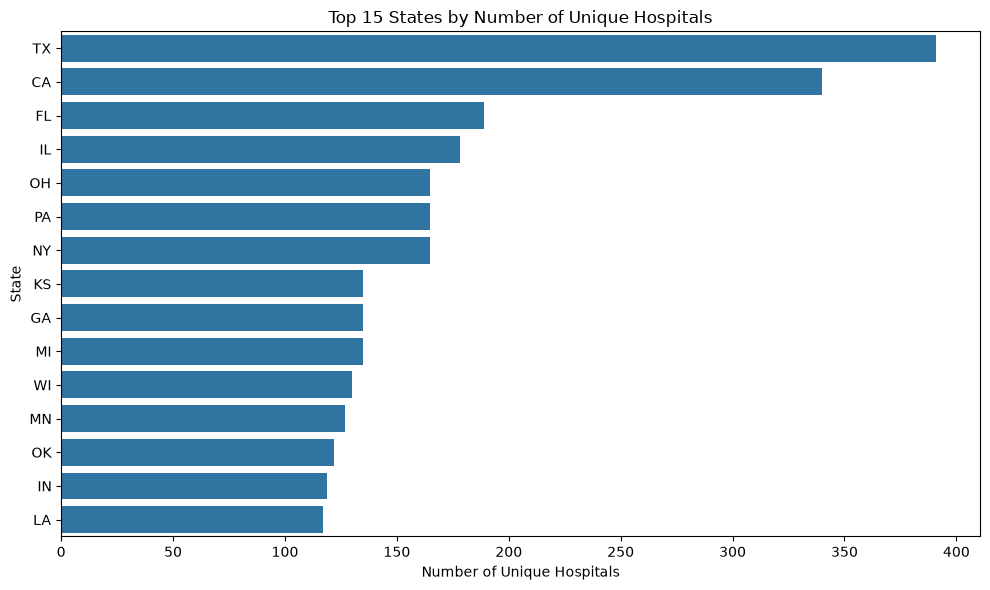

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

state_hospitals = (
    df.groupby("State")["Facility ID"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=state_hospitals.values,
    y=state_hospitals.index
)

plt.title("Top 15 States by Number of Unique Hospitals")
plt.xlabel("Number of Unique Hospitals")
plt.ylabel("State")
plt.tight_layout()
plt.show()

2.Distribution of Patient Return Rate

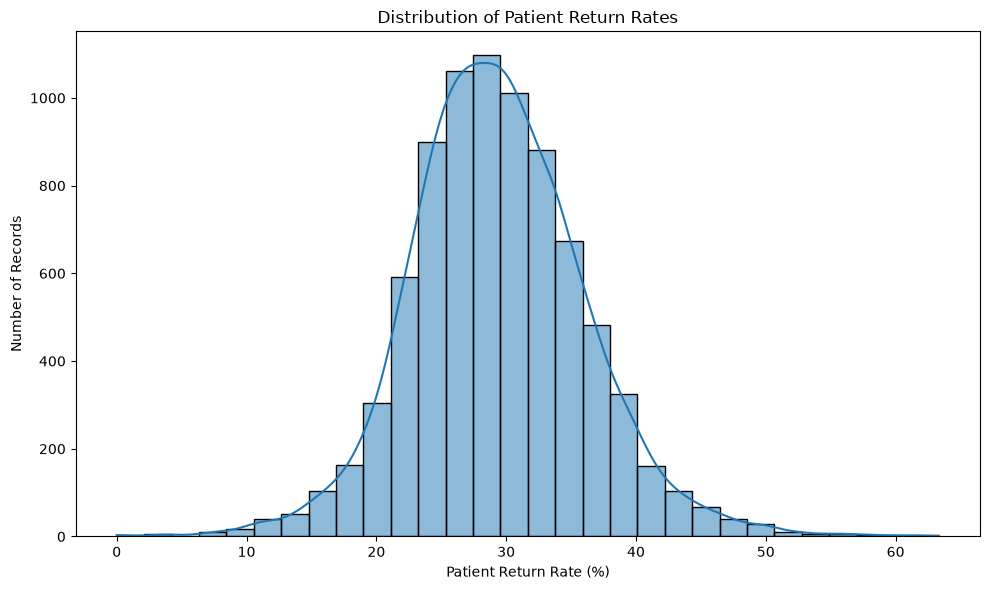

In [67]:
plt.figure(figsize=(10, 6))

sns.histplot(
    patient_df["Return Rate"],
    bins=30,
    kde=True
)

plt.title("Distribution of Patient Return Rates")
plt.xlabel("Patient Return Rate (%)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [70]:
df.to_excel(
    r"C:\Users\YUVRA\OneDrive\Desktop\1.STUDY\CMS analysis\CMS_Cleaned.xlsx",
    index=False
)

print("Excel file created successfully!")

Excel file created successfully!
